In [1]:
!pip install scipy

In [2]:
import pandas as pd 
import numpy as np 
import os 
import seaborn as sns
import matplotlib.pyplot as plt 
import missingno as msno
# models
from sklearn.cluster import KMeans,DBSCAN
from scipy.cluster.hierarchy import linkage,dendrogram,cut_tree

In [3]:
df=pd.read_csv(r"C:\Users\Admin\Downloads\iris (2)\iris.data.csv")
df.head(10)

,5.1,3.5,1.4,0.2,Iris-setosa
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa
5,4.6,3.4,1.4,0.3,Iris-setosa
6,5.0,3.4,1.5,0.2,Iris-setosa
7,4.4,2.9,1.4,0.2,Iris-setosa
8,4.9,3.1,1.5,0.1,Iris-setosa
9,5.4,3.7,1.5,0.2,Iris-setosa


# 1. DATA PROCESSING

In [4]:
df=pd.read_csv((r"C:\Users\Admin\Downloads\iris (2)\iris.data.csv"),
               header=None,names=["sepal_length","Sepal_width","Petal_length","Petal_width","classes"],index_col=None)
df.head(10)

,sepal_length,Sepal_width,Petal_length,Petal_width,classes
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [5]:
df.shape

(150, 5)

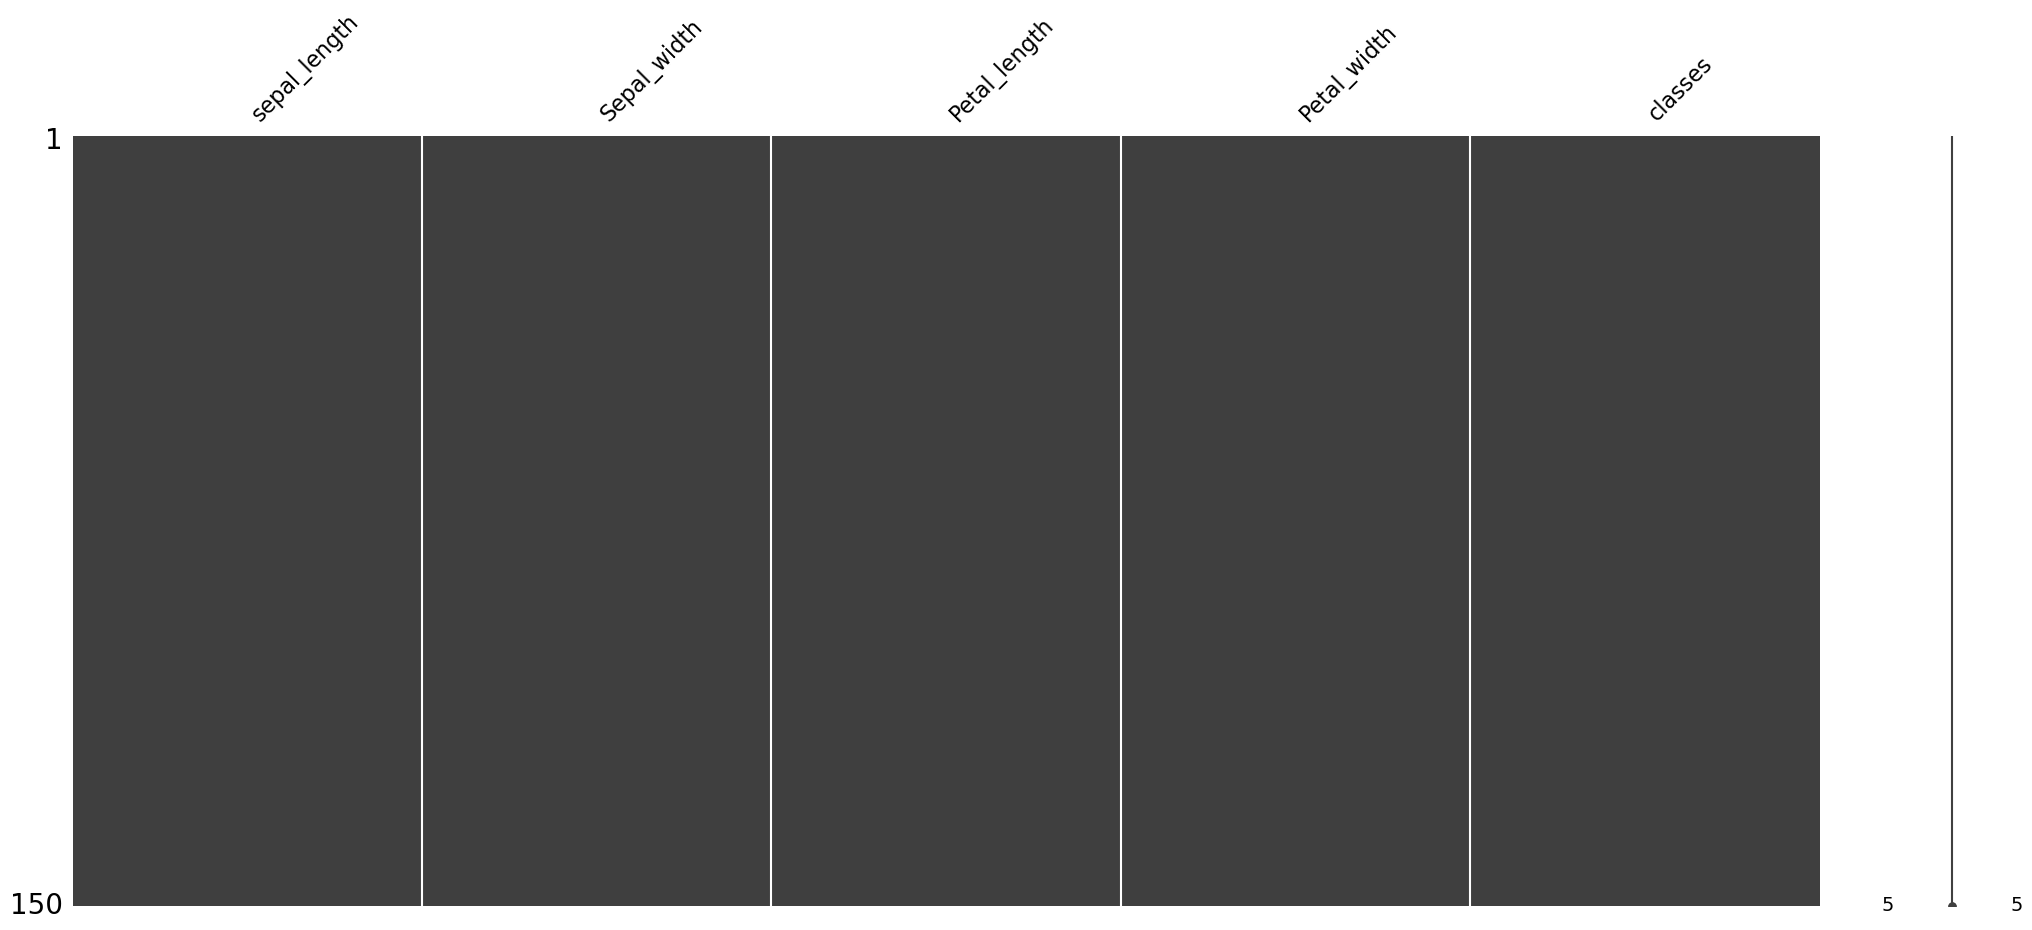

In [6]:
# plt.figure(figsize=(600,200)) 
msno.matrix(df)
plt.show()

<!-- 2.DATA RECTIFICATION -->

 # 1.2 RECTIFICATION

In [7]:
# correcting 38 row to [4.9,3.1,1.5,0.2,"Iris-setosa"]
df.iloc[34]=[4.9,3.1,1.5,0.2,"Iris-setosa"]
print("35:",df.iloc[34],sep="\n")
# correcting 36 row to [4.9,3.6,1.4,0.1,"Iris-setosa"]
df.iloc[36]=[4.9,3.6,1.4,0.1,"Iris-setosa"]
print("38:",df.iloc[36],sep="\n")

35:
sepal_length            4.9
Sepal_width             3.1
Petal_length            1.5
Petal_width             0.2
classes         Iris-setosa
Name: 34, dtype: object
38:
sepal_length            4.9
Sepal_width             3.6
Petal_length            1.4
Petal_width             0.1
classes         Iris-setosa
Name: 36, dtype: object


In [8]:
df.isnull()

,sepal_length,Sepal_width,Petal_length,Petal_width,classes
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


# 1.3 DATA CLEANING 

In [9]:
df.isnull().sum()

sepal_length    0
Sepal_width     0
Petal_length    0
Petal_width     0
classes         0
dtype: int64

In [10]:
print("Number of Duplicated SUM")
df.duplicated().sum()

Number of Duplicated SUM


2

In [11]:
# dropping the duplicated values 
df=df.drop_duplicates()
df.sort_index(axis=1)
df.shape

(148, 5)

# DATA TRANSFORMATION

classes
Iris-versicolor    50
Iris-setosa        49
Iris-virginica     49
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_2464\2900284044.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["classes"],palette="Set2")


<Axes: xlabel='classes', ylabel='count'>

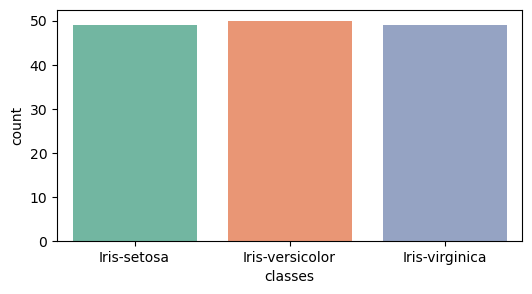

In [12]:
labels=["Iris-setosa","Iris-versicolor","Iris-virginica"]
print(df['classes'].value_counts())
plt.figure(figsize=(6,3))
sns.countplot(x=df["classes"],palette="Set2")

In [13]:
# mutual label encoding
y=df['classes']
n_y=[]
for i in y :
    n_y.append(labels.index(i))
df["classes"]=n_y

In [14]:
df["classes"].value_counts()

classes
1    50
0    49
2    49
Name: count, dtype: int64

In [15]:
df.iloc[0]

sepal_length    5.1
Sepal_width     3.5
Petal_length    1.4
Petal_width     0.2
classes         0.0
Name: 0, dtype: float64

In [16]:
labels[0]

'Iris-setosa'

<Axes: xlabel='classes', ylabel='count'>

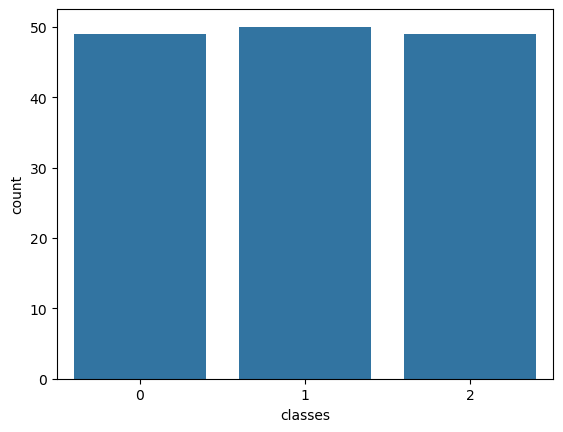

In [17]:
sns.countplot(x=df["classes"])

# 2. DATA VISUALIZATION

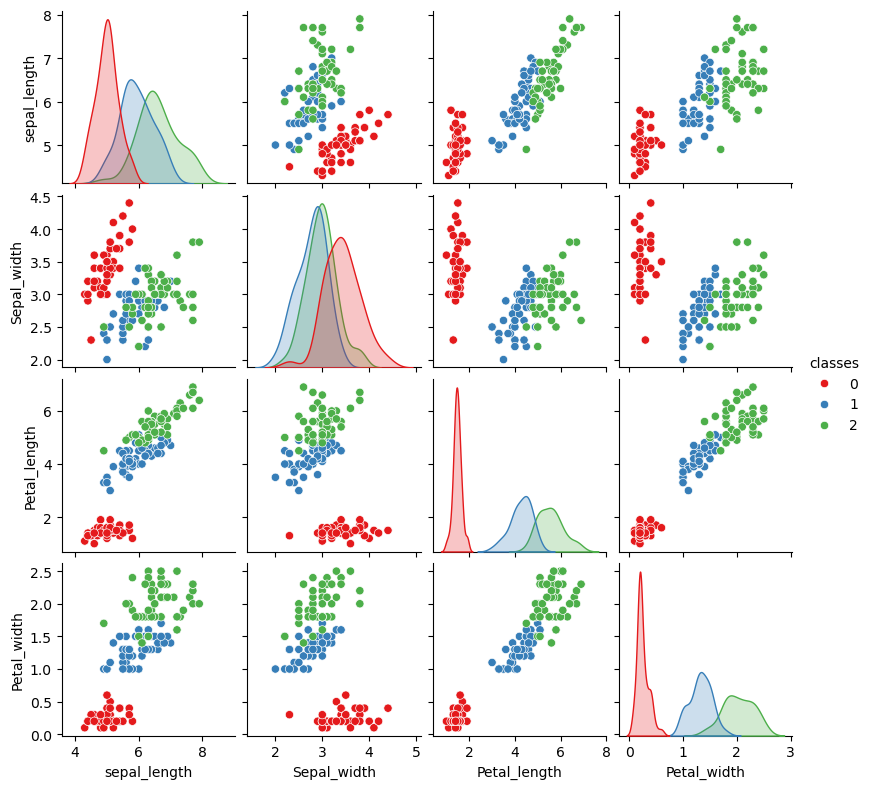

In [18]:
# plot the dataset 
sns.pairplot(df,hue="classes",height=2,diag_kind="kde",palette="Set1")
plt.show()

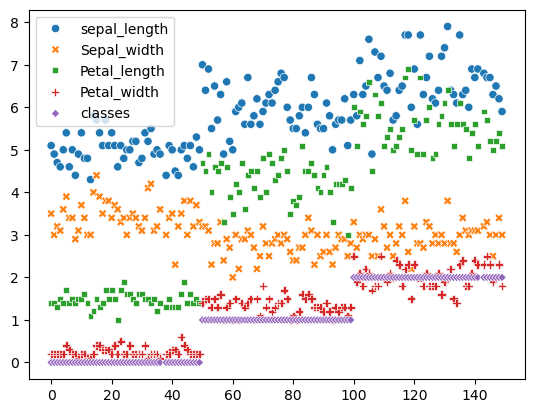

In [19]:
sns.scatterplot(data=df)
plt.show()

# 3. DATA PREPARATION

In [20]:
# splits the data into X y terms 
X,y=df.drop("classes",axis=1),df["classes"]
print("shape of X",X.shape)
print("shape of y",y.shape)

shape of X (148, 4)
shape of y (148,)


# 4. MODEL BUILDING

### 4.1 K-MEANS CLUSTERING 

In [21]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=5,random_state=21)
y_predict=kmeans.fit_predict(X)
print(y_predict)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 2 1 2 1 2 1 2 2 1 2 1 2 1 1 2 1 2 1 2 1 1 1
 1 1 1 1 2 2 2 2 1 2 1 1 1 2 2 2 1 2 2 2 2 2 1 2 2 4 1 3 4 4 3 2 3 4 3 4 4
 4 1 4 4 4 3 3 1 4 1 3 1 4 3 1 1 4 3 3 3 4 1 1 3 4 4 1 4 4 4 4 4 4 1 4 4 1]


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [22]:
# we can check the centroids that can be created by the model
kmeans.cluster_centers_

array([[4.99591837, 3.42653061, 1.46530612, 0.24693878],
       [6.23243243, 2.85945946, 4.74324324, 1.56216216],
       [5.51538462, 2.60769231, 3.93076923, 1.20769231],
       [7.475     , 3.125     , 6.3       , 2.05      ],
       [6.52916667, 3.05833333, 5.50833333, 2.1625    ]])

In [23]:
# DEFINE COLOuR PALATTE
colour_palette=sns.color_palette("icefire",as_cmap=True)

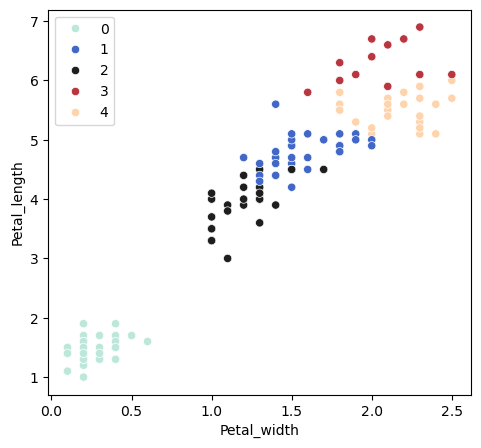

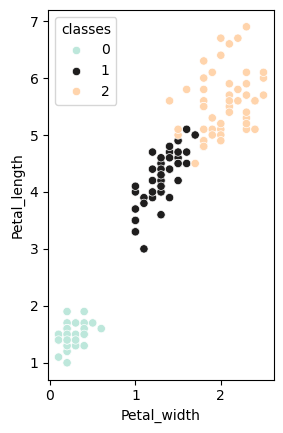

In [24]:
# fig,ax=plt.subplots(1,2,figsize=(12,5))
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title=("KMeans CLUSTERING")
sns.scatterplot(x=X["Petal_width"],y=X["Petal_length"],hue=y_predict,palette=colour_palette)
plt.show()

plt.subplot(1,2,2)
plt.title=("original Clustering")
sns.scatterplot(x=X["Petal_width"],y=X["Petal_length"],hue=y,palette=colour_palette)
plt.show()

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

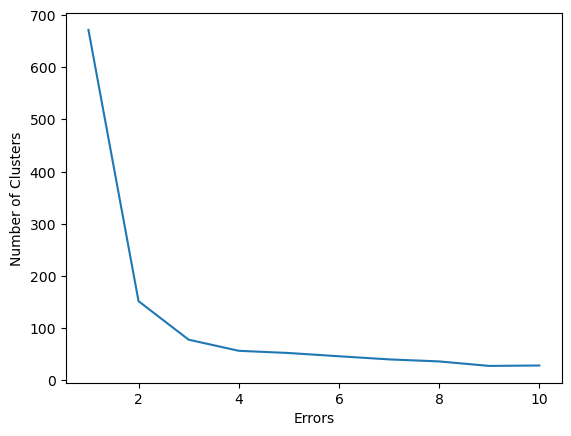

[671.5847972972973, 151.6530608974359, 77.82860125588698, 56.5497090855573, 52.277062167258194, 46.08834280303029, 40.06276583436405, 36.177408145076214, 27.54839513556619, 28.375529802577283]


In [25]:
error=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i).fit(X)
    kmeans.fit(X)
    error.append(kmeans.inertia_)

plt.plot(range(1,11),error)
plt.title=("Elbow Curve")
plt.xlabel("Errors")
plt.ylabel("Number of Clusters")
plt.show()
print(error)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 1 1 1 1 2 1 1 1 1 1
 1 2 2 1 1 1 1 2 1 2 1 2 1 1 2 2 1 1 1 1 1 2 1 1 1 1 2 1 1 1 1 1 1 2 1 1 2]


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


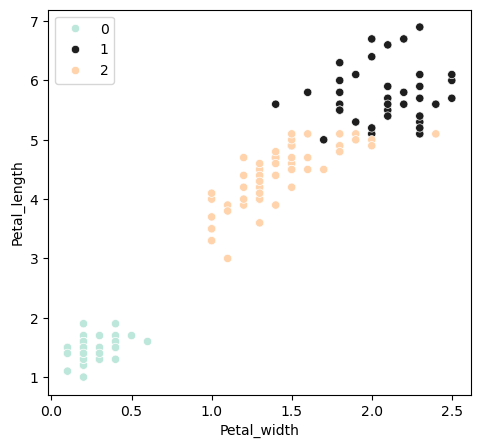

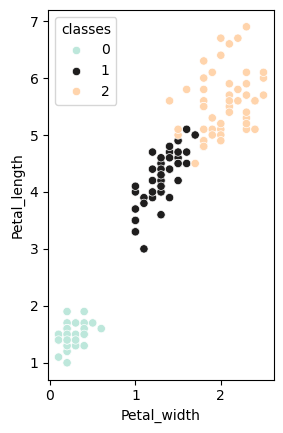

In [26]:
kmeans=KMeans(n_clusters=3,random_state=21)
y_predict=kmeans.fit_predict(X)
print(y_predict)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title=("KMeans CLUSTERING")
sns.scatterplot(x=X["Petal_width"],y=X["Petal_length"],hue=y_predict,palette=colour_palette)
plt.show()

plt.subplot(1,2,2)
plt.title=("original Clustering")
sns.scatterplot(x=X["Petal_width"],y=X["Petal_length"],hue=y,palette=colour_palette)
plt.show()

In [27]:
# check the count difference with respect to graph
print("Original Clustering Count:",y.value_counts(),sep="\n",end="\n\n")
print("Predicted Clustering Count :",pd.Series(y_predict).value_counts(),sep="\n",end="\n\n")

Original Clustering Count:
classes
1    50
0    49
2    49
Name: count, dtype: int64

Predicted Clustering Count :
2    60
0    49
1    39
Name: count, dtype: int64



## 4.2 Hirarchical Clustering

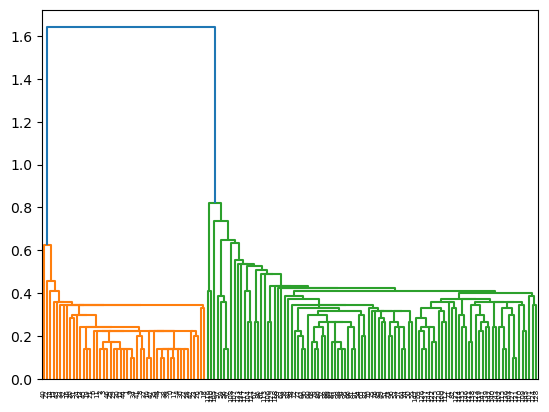

In [28]:
from scipy.cluster.hierarchy import linkage,dendrogram,cut_tree
# single linkage
merging=linkage(X,method="single",metric="euclidean")
dendrogram(merging)
plt.show()

In [29]:
clusters_labels_single = cut_tree(merging,n_clusters=3).reshape(-1)
clusters_labels_single

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int64)

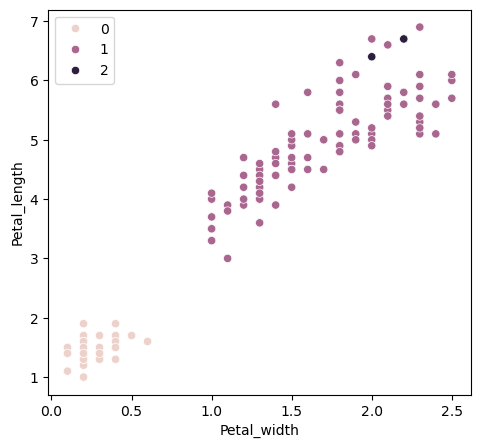

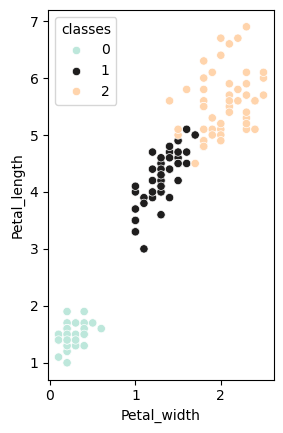

Original Clustering Count:
classes
1    50
0    49
2    49
Name: count, dtype: int64

Predicted Clustering Count :
1    97
0    49
2     2
Name: count, dtype: int64



In [30]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title=("Hirarchical Clustering")
sns.scatterplot(x=X["Petal_width"],y=X["Petal_length"],hue=clusters_labels_single)
plt.show()

plt.subplot(1,2,2)
plt.title=("original Clustering")
sns.scatterplot(x=X["Petal_width"],y=X["Petal_length"],hue=y,palette=colour_palette)
plt.show()
print("Original Clustering Count:",y.value_counts(),sep="\n",end="\n\n")
print("Predicted Clustering Count :",pd.Series(clusters_labels_single).value_counts(),sep="\n",end="\n\n")

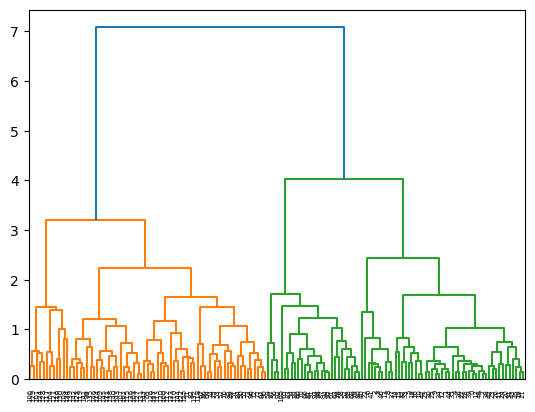

In [31]:
# complete linkage
merging_2=linkage(X,method="complete",metric="euclidean")
dendrogram(merging_2)
plt.show()

In [32]:
clusters_labels_complete = cut_tree(merging_2,n_clusters=3).reshape(-1)
clusters_labels_complete

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 2, 1, 2, 1, 2, 1, 2, 2, 2, 2, 1, 2, 1, 2,
       2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 1, 2, 1, 1, 1, 2,
       2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int64)

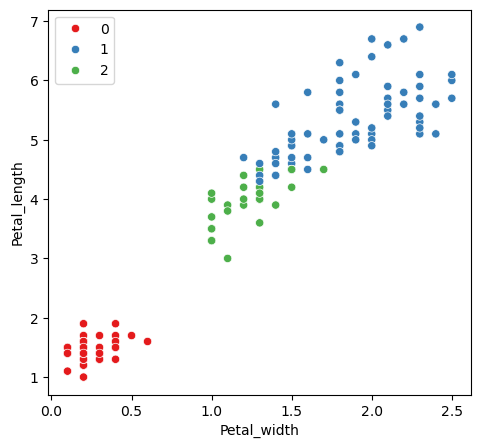

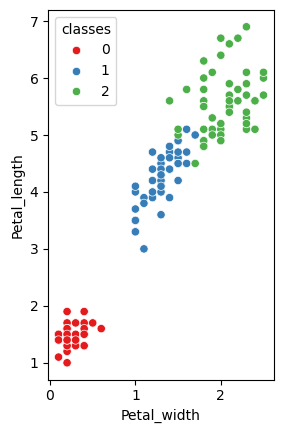

Original Clustering Count:
classes
1    50
0    49
2    49
Name: count, dtype: int64

Predicted Clustering Count :
1    71
0    49
2    28
Name: count, dtype: int64



In [33]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title=("Hirarchical Clustering")
sns.scatterplot(x=X["Petal_width"],y=X["Petal_length"],hue=clusters_labels_complete,palette="Set1")
plt.show()

plt.subplot(1,2,2)
plt.title=("original Clustering")
sns.scatterplot(x=X["Petal_width"],y=X["Petal_length"],hue=y,palette="Set1")
plt.show()
print("Original Clustering Count:",y.value_counts(),sep="\n",end="\n\n")
print("Predicted Clustering Count :",pd.Series(clusters_labels_complete).value_counts(),sep="\n",end="\n\n")

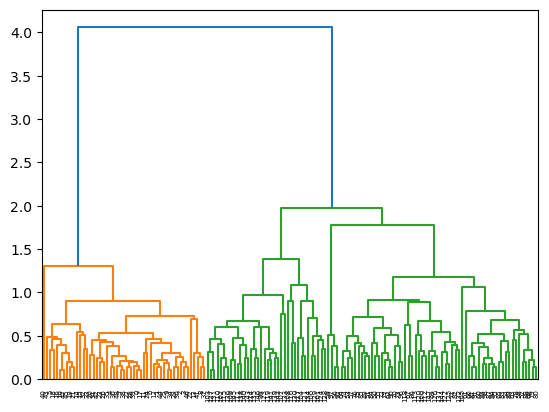

In [34]:
# average linkage 
merging_3=linkage(X,method="average",metric="euclidean")
dendrogram(merging_3)
plt.show()

In [35]:
cluster_labels_average =cut_tree(merging_3,n_clusters=3).reshape(-1)
cluster_labels_average 

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2,
       2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2, 2,
       1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 1], dtype=int64)

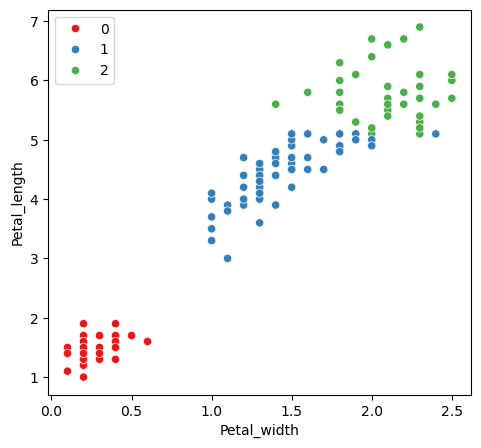

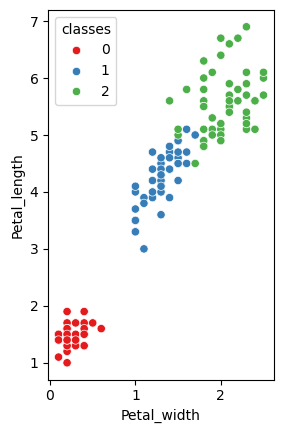

Original Clustering Count:
classes
1    50
0    49
2    49
Name: count, dtype: int64

Predicted Clustering Count :
1    63
0    49
2    36
Name: count, dtype: int64



In [36]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title=("Hirarchical Clustering")
sns.scatterplot(x=X["Petal_width"],y=X["Petal_length"],hue=cluster_labels_average,palette="Set1")
plt.show()

plt.subplot(1,2,2)
plt.title=("original Clustering")
sns.scatterplot(x=X["Petal_width"],y=X["Petal_length"],hue=y,palette="Set1")
plt.show()
print("Original Clustering Count:",y.value_counts(),sep="\n",end="\n\n")
print("Predicted Clustering Count :",pd.Series(cluster_labels_average).value_counts(),sep="\n",end="\n\n")

## 4.3 DBSCAN

In [37]:
dbscan=DBSCAN()
db_clusters=dbscan.fit_predict(X)
db_clusters
# -1 refers to the noise and should'not be consider as another clusters 

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,
        1,  1,  1,  1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1, -1, -1,  1, -1, -1,  1,  1,  1,  1,  1,  1,  1, -1, -1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1, -1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1], dtype=int64)

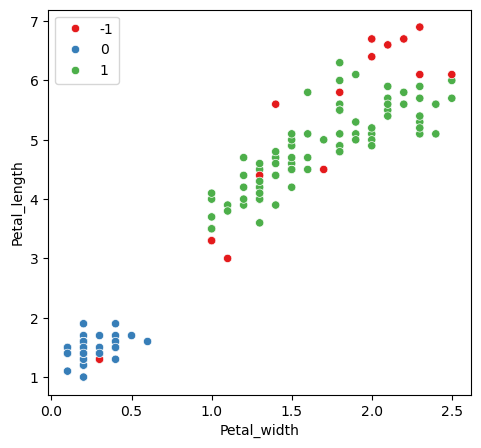

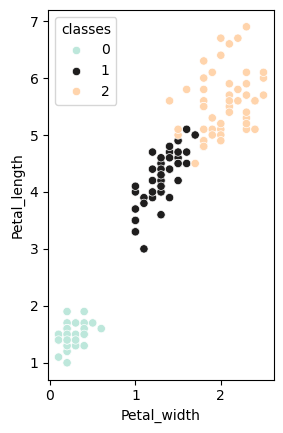

Original Clusters count :
classes
1    50
0    49
2    49
Name: count, dtype: int64

Original Clusters count :
 1    83
 0    48
-1    17
Name: count, dtype: int64



In [38]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title=("DBScan Clustering")
sns.scatterplot(x=X["Petal_width"],y=X["Petal_length"],hue=db_clusters,palette="Set1")
plt.show()

plt.subplot(1,2,2)
plt.title=("Original clustering")
sns.scatterplot(x=X["Petal_width"],y=X["Petal_length"],hue=y,palette=colour_palette)
plt.show()

# values 
print("Original Clusters count :",y.value_counts(),sep="\n",end="\n\n")
print("Original Clusters count :",pd.Series(db_clusters).value_counts(),sep="\n",end="\n\n")

## 4.4 PREDICTING THE DATA

In [39]:
# KMeans 
y_predict_kmeans = kmeans.predict(X)

# Hierachical Clustering 
y_predict_hierachical = cut_tree(merging ,n_clusters=3).reshape(-1)

# DBScan Clustering
y_predict_dbscan=dbscan.fit_predict(X)

In [40]:
from sklearn.metrics.cluster import adjusted_rand_score

# KMeans Perfomance 
print("ARI of KMeans : ",adjusted_rand_score(y,y_predict_kmeans))

#hierachical Perfomance 
print("ARI of Hierachical : ",adjusted_rand_score(y,y_predict_hierachical))

# DBScan Perfomance 
print("ARI of DBScan : ",adjusted_rand_score(y,y_predict_dbscan))

ARI of KMeans :  0.7255753947199401
ARI of Hierachical :  0.5615264885623266
ARI of DBScan :  0.5180407839232024


In [79]:
df1=pd.read_csv(r"E:\machine learning\data sets\Campus_Selection.csv")
df1.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed
